Tour validity: True
Mean edge length: 0.7248256454871114
Mean |Δr|: 0.11986765916827503
Std Δθ: 0.7707585899557516
Observed mean Δθ (deg): 136.6437547763148
Expected golden angle (deg): 137.50776
Bin uniformity check:
  mean bin fill: 7.142857142857143 std: 3.3457252653229625
 [108.83453628 138.80860983 160.66513409]


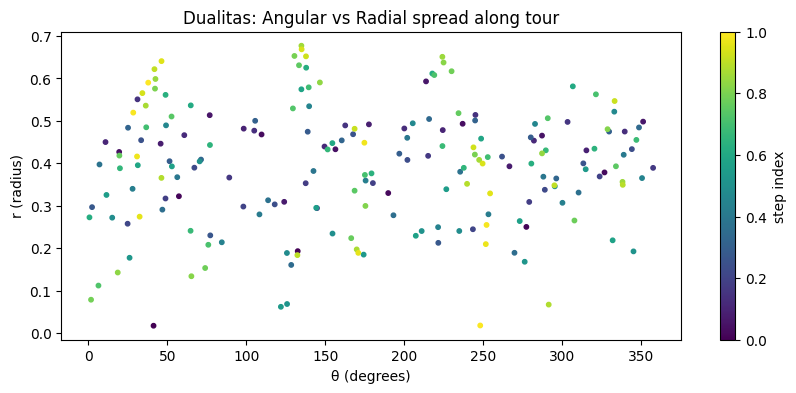

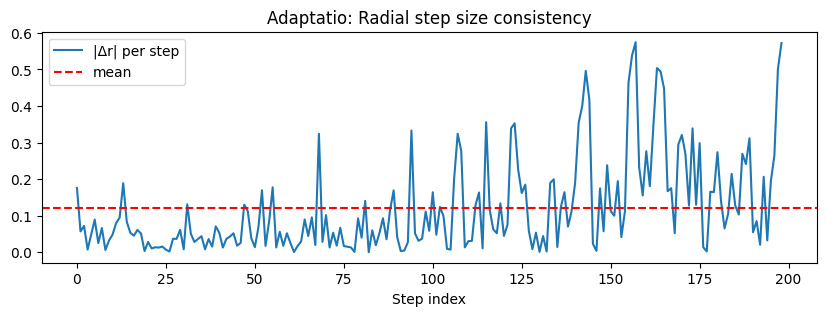

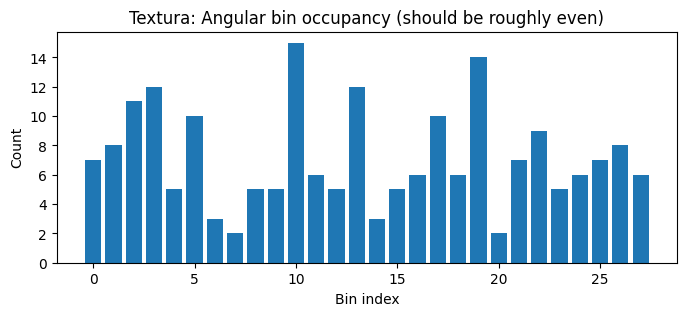

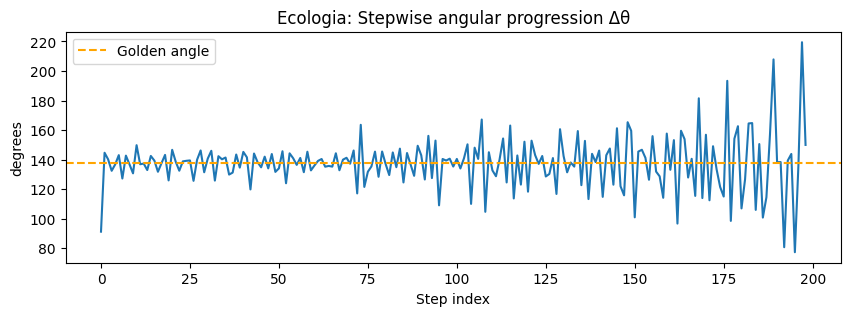

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gao_spiral import gao_spiral, GAOParams, centroid, to_polar, euclid

# --- Generate a sample dataset ---
np.random.seed(42)
n = 200
points = np.random.rand(n, 2)
params = GAOParams()

# --- Run GAO Spiral ---
tour = gao_spiral(points.tolist(), params)
C = centroid(points)
r, theta = to_polar(points, C)
r = np.array(r); theta = np.array(theta)

# --- Reorder polar coordinates along the tour ---
r_t = r[tour]; theta_t = np.unwrap(theta[tour])

# --- Compute local deltas ---
dr = np.diff(r_t)
dtheta = np.diff(theta_t)
edge_lengths = [euclid(points[tour[i]], points[tour[(i+1)%n]]) for i in range(n)]
mean_edge = np.mean(edge_lengths)

# --- Core checks ---
print("Tour validity:", len(set(tour)) == n)
print("Mean edge length:", mean_edge)
print("Mean |Δr|:", np.mean(np.abs(dr)))
print("Std Δθ:", np.std(dtheta))
print("Observed mean Δθ (deg):", np.degrees(np.mean(np.abs(dtheta))) % 360)
print("Expected golden angle (deg):", 137.50776)
print("Bin uniformity check:")  # Trinitas/Textura
B = int(2*np.sqrt(n))
hist, _ = np.histogram(theta, bins=B)
print("  mean bin fill:", np.mean(hist), "std:", np.std(hist))
print("", np.percentile(np.degrees(np.abs(dtheta)), [5,50,95]))

# --- Dualitas: radius vs angle interplay ---
plt.figure(figsize=(10,4))
plt.scatter(np.degrees(theta_t % (2*np.pi)), r_t, s=10, c=np.linspace(0,1,n))
plt.xlabel("θ (degrees)")
plt.ylabel("r (radius)")
plt.title("Dualitas: Angular vs Radial spread along tour")
plt.colorbar(label="step index")
plt.show()

# --- Adaptatio: local flow coherence ---
plt.figure(figsize=(10,3))
plt.plot(np.abs(dr), label="|Δr| per step")
plt.axhline(np.mean(np.abs(dr)), color='r', linestyle='--', label="mean")
plt.title("Adaptatio: Radial step size consistency")
plt.xlabel("Step index")
plt.legend()
plt.show()

# --- Textura: bin occupancy histogram ---
plt.figure(figsize=(8,3))
plt.bar(range(B), hist)
plt.title("Textura: Angular bin occupancy (should be roughly even)")
plt.xlabel("Bin index")
plt.ylabel("Count")
plt.show()

# --- Ecologia: rotational rhythm stability ---
plt.figure(figsize=(10,3))
plt.plot(np.degrees(dtheta % (2*np.pi)))
plt.axhline(137.50776, color='orange', linestyle='--', label="Golden angle")
plt.title("Ecologia: Stepwise angular progression Δθ")
plt.ylabel("degrees")
plt.xlabel("Step index")
plt.legend()
plt.show()

In [2]:
from math import pi, degrees

def gao_coherence_scores(points, tour, r, theta, verbose=True):
    """
    Compute quantitative coherence metrics for GAO Spiral geometry.
    Returns a dict of normalized scores (0–1 range, higher = better).
    """

    n = len(points)
    r = np.array(r)
    theta = np.unwrap(theta)
    r_t = r[tour]
    theta_t = theta[tour]
    dr = np.diff(r_t)
    dtheta = np.diff(theta_t)
    B = int(2*np.sqrt(n))
    hist, _ = np.histogram(theta, bins=B)

    # --- Dualitas: coupling of radius & angle (correlation stability) ---
    corr = np.corrcoef(r_t[:-1], np.degrees(theta_t[:-1]) % 360)[0,1]
    dualitas_score = 1 - abs(corr)  # near-zero correlation → balanced polarity

    # --- Adaptatio: smoothness of radial flow ---
    mean_dr = np.mean(np.abs(dr))
    std_dr = np.std(np.abs(dr))
    adaptatio_score = 1 / (1 + std_dr / (mean_dr + 1e-9))  # lower variability → higher score

    # --- Textura: uniform bin occupancy ---
    cv_bins = np.std(hist) / (np.mean(hist) + 1e-9)
    textura_score = 1 / (1 + cv_bins)  # coefficient of variation

    # --- Ecologia: angular rhythm stability ---
    golden = 137.50776
    mean_dtheta = np.degrees(np.mean(np.abs(dtheta))) % 360
    std_dtheta = np.std(np.degrees(np.abs(dtheta)))
    ecologia_score = 1 / (1 + abs(mean_dtheta - golden)/golden + std_dtheta/180)

    # Aggregate: simple harmonic mean for overall coherence
    scores = {
        "Dualitas": dualitas_score,
        "Adaptatio": adaptatio_score,
        "Textura": textura_score,
        "Ecologia": ecologia_score
    }
    overall = np.mean(list(scores.values()))
    scores["Overall"] = overall

    if verbose:
        print("=== GAO Coherence Scores ===")
        for k,v in scores.items():
            print(f"{k:10s}: {v:6.3f}")
        print("============================")

    return scores

# --- Run the scoring function on current GAO output ---
scores = gao_coherence_scores(points, tour, r, theta)


=== GAO Coherence Scores ===
Dualitas  :  0.950
Adaptatio :  0.482
Textura   :  0.507
Ecologia  :  0.171
Overall   :  0.527
